In [1]:
# Como siempre primero importamos nuestro modulo de simulacion
from tripodpy import Simulation

In [2]:
# Inicializamos la simulacion
sim = Simulation()  

## Customizando el grid de nuestro frame de simulacion :D

Por defecto, al inicializar la simulacion `Simulation.initialize()` creara el grid con los parametros default. Pero es posible personalizar este grid. En el caso de que personalicemos debemos inicializar el grid de la sigueinte manera 
`Simulation.makegrids()`, asi solo iniciamos el grid pero no los parametro de la simulacion.

In [3]:
sim.grid

Group (Grid quantities)
-----------------------
    A            : NoneType
    Nr           : NoneType
    OmegaK       : NoneType
    r            : NoneType
    ri           : NoneType
  -----

In [4]:
sim.makegrids()
sim.grid

Group (Grid quantities)
-----------------------
    A            : Field (Radial grid annulus area [cm²]), constant
    Nr           : Field (# of radial grid cells), constant
    r            : Field (Radial grid cell centers [cm]), constant
    ri           : Field (Radial grid cell interfaces [cm]), constant
  -----
    OmegaK       : NoneType
  -----

vemos que $\Omega_k$ no se inicializa aun, esto se debe a que 
<div align = "center">

$$
\Omega_k = \Omega_k(M_\star, R)
$$

</div>

con $M_\star$ la masa de la estrella y $R$ la distancia al centro 

In [5]:
radius_ratio = sim.grid.r[1:]/sim.grid.r[:-1]
print('maximum ratio=', max(radius_ratio),'; minimum ratio=', min(radius_ratio))

maximum ratio= 1.0715193052376093 ; minimum ratio= 1.0715193052376046


Como tripodpy construye la grilla es en escala logaritmica (mayor resolucion a distnacias más pequeñas, donde el grandiente de presion es mayor), de tal manera que el grid es equidistnate en escala logaritmica.

Nosotros podemos personalizar los bordes de la grilla, como ya vimos en el notebook de `personalizacion.ipynb` (`Simulation.ini.grid`). Luego cuando inicializamos el grid con `Simulation.makegrids()` toma los valores que les dimo y crea el grid. Pero esto solo crea grillas logaritmicamente uniformes, que pasa si queremos más resolución en cierta distancia del disco? No sería posible solo con los parametros iniciales.

Ahora, hablemos de los parametros de `Simulation.grid`: 

`Simulation.grid.A`: Área de cada anillo de la grilla radial del disco. Asociada a cada celda. Util para convertir densidades a masas. Segun yo la formula sera algo como:

<div align="center">

$$
A_i = \pi (r_{i+1}^2 - r_{i}^2)
$$

</div>

`Simulation.grid.Nr`: Cantidad de celdas que tiene la grilla. Default son 100

`Simulation.grid.r`: Distancia entre el centro del disco y el centro de cada celda calculada en [cm]

El centro en este caso sería el promedio entre los bordes de cada celda.

`Simulation.grid.ri`: Distancia entre el centro y los bordes de cada celda.







---    
De esta manera, notamos que todos estos datos son arrays mutables, es decir, modificables a gustos. El ejercicio ahora es crear una grilla personalizada.
---


La siguiente funcion toma un una lista de distancias de interfaces ri, ademas de una distancia a la que queremos generar mas "resolucion" r0 y las iteración de resolucion extra que queremos num. lo que hace es que agarra la vecindad de r0 y las subdivide a la mitad, lo hace `num` veces de manera iterativa.

[Dustpylib grid refine](https://github.com/stammler/dustpylib/blob/main/dustpylib/grid/refinement/refinement.py)

In [23]:
import numpy as np

def refinegrid(ri, r0, num=3):
    """Function to refine the radial grid

    Parameters
    ----------
    ri : array
        Radial interfaces
    r0 : float
        Radial location around which grid should be refined
    num : int, option, default : 3
        Number of refinement iterations

    Returns
    -------
    ri : array
        New refined radial grid"""
    if num == 0:
        return ri
    for _ in range(num):
        ind = np.argmin(r0 > ri) - 1
        ind_left  = ind-num
        ind_right = ind+num+1
        ri_left  = ri[:ind_left]
        ri_right = ri[ind_right:]
        number_refined_cells = (2*num+1)*2
        ri_mid = np.empty(number_refined_cells)
        for i in range(0, number_refined_cells, 2):
            j = ind-num+int(i/2)
            ri_mid[i] = ri[j]
            ri_mid[i+1] = 0.5*(ri[j]+ri[j+1])
        ri = np.concatenate((ri_left, ri_mid, ri_right))
    return ri

In [26]:
import numpy as np
import dustpy.constants as c

# Esta funcion fue extraido de dustpylib, funcion auxiliar para modificar la grilla de una 
# simulacion
def refine_radial_local(ri, r0, num=3):
    """
    Refina la grilla radial logarítmicamente alrededor de r0.
    En cada nivel recursivo inserta el punto medio geométrico
    sqrt(r_i * r_{i+1}) dentro de una ventana centrada en r0.
    La ventana se reduce en cada llamada (num-1), concentrando
    el refinamiento cerca de r0.
    Parameters
    ----------
    ri : np.ndarray, shape (Nr+1,)
        Interfaces de la grilla radial [cm]
    r0 : float
        Radio alrededor del cual refinar [cm]
    num : int, optional, default=3
        Número de niveles de refinamiento
    Returns
    -------
    ri_fine : np.ndarray
        Grilla refinada [cm]
    """
    if num == 0:
        return ri
    # Índice de la interfaz inmediatamente a la izquierda de r0
    i0 = np.argmax(ri > r0) - 1
    # Límites de la ventana de refinamiento
    il = max(0, i0 - num + 1)
    ir = min(i0 + num, ri.shape[0] - 1)
    # Regiones sin modificar
    ril = ri[:il]
    rir = ri[ir:]
    # Región refinada: media geométrica (= punto medio en log-space)
    N = ir - il
    rim = np.empty(2 * N)
    for i in range(N):
        j = il + i
        rim[2 * i]     = ri[j]
        rim[2 * i + 1] = np.sqrt(ri[j] * ri[j + 1])
    ri_fine = np.concatenate((ril, rim, rir))
    # Siguiente nivel de recursión con ventana más chica
    return refine_radial_local(ri_fine, r0, num=num - 1)

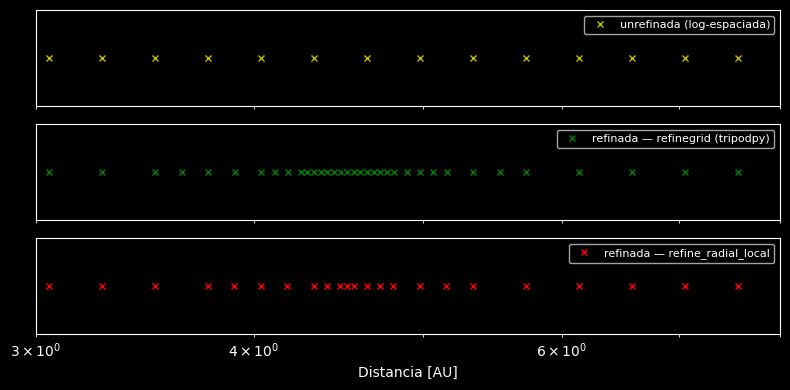

In [37]:
import dustpy.constants as c
import numpy as np
# Creamos una grilla, de 1 a 100 UA, 100 celdas log-espaciados
ri_unrefine = np.logspace(0., 3., num=100, base=10.) * c.au

# Ahora redefinimos la grilla con el refine de tripodpy y luego con el dustpylib

ri_tripodpy = refinegrid(ri_unrefine, 4.5*c.au, num = 3)

ri_dustpylib = refine_radial_local(ri_unrefine, 4.5*c.au, num=3)


import matplotlib.pyplot as plt
import dustpy.constants as c
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True)

grids = [
    (ri_unrefine,   'yx',  'unrefinada (log-espaciada)'),
    (ri_tripodpy,   'gx',  'refinada — refinegrid (tripodpy)'),
    (ri_dustpylib,  'rx',  'refinada — refine_radial_local'),
]

for ax, (ri, marker, label) in zip(axes, grids):
    ax.plot(ri / c.au, ri * 0, marker, ms=5, label=label)
    ax.set_xscale('log')
    ax.set_xlim(3, 8)
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Distancia [AU]')

# Línea vertical en r0
for ax in axes:
    ax.axvline(4.5, color='k', ls='--', lw=0.8, alpha=1)

plt.tight_layout()
plt.show()


---
Podemos crear ahora otro frame de simulacion para probar la nueva celda personalizada.

---

In [39]:
sim = Simulation()

sim.grid.ri = ri_tripodpy

sim.grid

Group (Grid quantities)
-----------------------
    A            : NoneType
    Nr           : NoneType
    OmegaK       : NoneType
    r            : NoneType
    ri           : ndarray
  -----

Notamos que ri es un objeto del tipo ndarray, tripodpy no tiene problema en inicializar con estas variables ya que luego las pasa a un objeto del tipo `simframe.Field`.

In [ ]:
sim.makegrids()
sim.grid

Group (Grid quantities)
-----------------------
    A            : Field (Radial grid annulus area [cm²]), constant
    Nr           : Field (# of radial grid cells), constant
    r            : Field (Radial grid cell centers [cm]), constant
    ri           : Field (Radial grid cell interfaces [cm]), constant
  -----
    OmegaK       : NoneType
  -----

In [46]:
# Como el largo de ri vario, tambien varia el numero de celdas
sim.grid.Nr

120

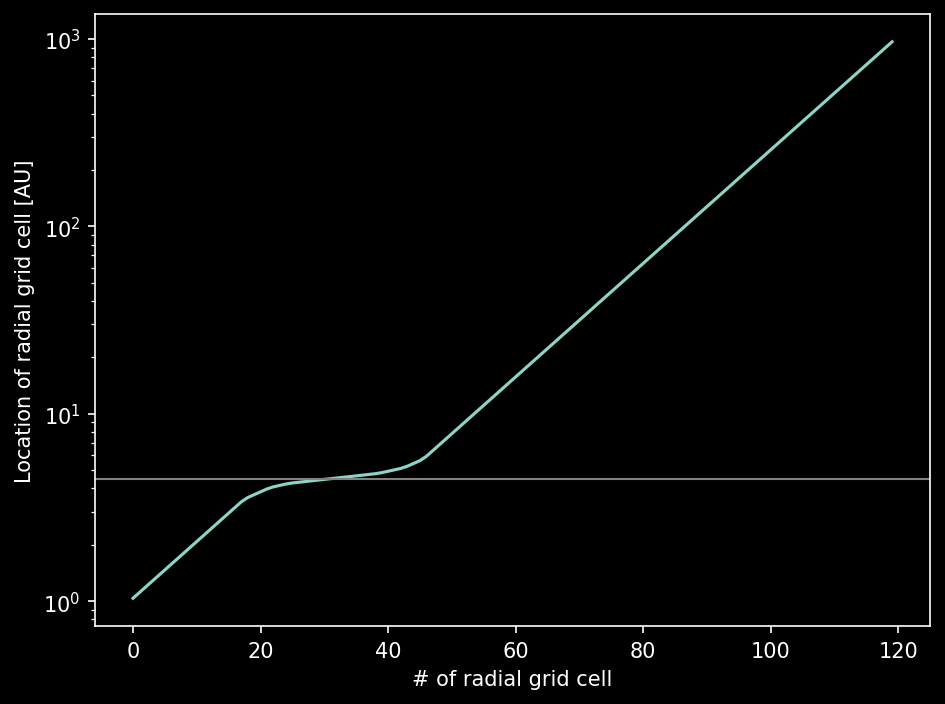

In [48]:
# Notamos que se actualizo el grid
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.semilogy(sim.grid.r/c.au)
ax.axhline(4.5, c="gray", lw=1)
ax.set_xlabel("# of radial grid cell")
ax.set_ylabel("Location of radial grid cell [AU]")
fig.tight_layout()
plt.show()